In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, pearsonr
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [9]:
df = pd.read_csv('data.csv')

print(f"Dataset shape: {df.shape}")
print(f"Number of respondents: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print(f"\nColumn names:\n{df.columns.tolist()}")

print(df.head())

print(df.dtypes)

print(df.isnull().sum())

Dataset shape: (200, 16)
Number of respondents: 200
Number of features: 16

Column names:
['Unnamed: 0', 'Age Group', 'Gender', 'Education Level', 'Occupation', 'Average Screen Time', 'Device', 'Screen Activity', 'App Category', 'Screen Time Period', 'Environment', 'Productivity', 'Attention Span', 'Work Strategy', 'Notification Handling', 'Usage of Productivity Apps']
   Unnamed: 0     Age Group  Gender Education Level    Occupation  \
0           0         18–24    Male   Undergraduate       Student   
1           1         18–24    Male   Undergraduate  Professional   
2           2  45 and above  Female        Graduate  Professional   
3           3         25–34    Male   Undergraduate  Professional   
4           4  45 and above    Male        Graduate  Professional   

  Average Screen Time      Device  \
0        More than 10  Smartphone   
1                8-10  Smartphone   
2                 4–6  Smartphone   
3                8-10   Laptop/PC   
4                8-10   Lapt

In [10]:
print(f"Missing values before cleaning:\n{df.isnull().sum()}")

df_clean = df.dropna(subset=['Environment', 'Work Strategy'])
print(f"\nRows after dropping missing values: {df_clean.shape[0]}")

df_clean.columns = df_clean.columns.str.strip()

productivity_map = {
    'Extremely productive, i efficiently complete my tasks': 3,
    'Moderately productive': 2,
    'Unproductive, i might not have completed the task and got carried away': 1
}

df_clean['Productivity_Score'] = df_clean['Productivity'].map(productivity_map)

screen_time_map = {
    'Less than 2': 1,
    '2–4': 2,
    '4–6': 3,
    '6–8': 4,
    '8-10': 5,
    'More than 10': 6
}

df_clean['Screen_Time_Numeric'] = df_clean['Average Screen Time'].map(screen_time_map)

attention_map = {
    'Less than 10 minutes': 1,
    '10–30 minutes': 2,
    '30–60 minutes': 3,
    'More than 1 hour': 4
}

df_clean['Attention_Span_Numeric'] = df_clean['Attention Span'].map(attention_map)

print(f"\nProductivity Score distribution:")
print(df_clean['Productivity_Score'].value_counts())
print(f"\nScreen Time Numeric distribution:")
print(df_clean['Screen_Time_Numeric'].value_counts())

def app_helpful(value):
    if pd.isna(value):
        return 0
    if 'Yes, they are extremely helpful' in str(value):
        return 2
    elif 'Yes, but i did not find them of any help' in str(value):
        return 1
    else:
        return 0

df_clean['App_Helpfulness'] = df_clean['Usage of Productivity Apps'].apply(app_helpful)

print(f"Final dataset shape: {df_clean.shape}")

Missing values before cleaning:
Unnamed: 0                    0
Age Group                     0
Gender                        0
Education Level               0
Occupation                    0
Average Screen Time           0
Device                        0
Screen Activity               0
App Category                  0
Screen Time Period            0
Environment                   2
Productivity                  0
Attention Span                0
Work Strategy                 3
Notification Handling         1
Usage of Productivity Apps    0
dtype: int64

Rows after dropping missing values: 196

Productivity Score distribution:
Productivity_Score
2    106
3     53
1     37
Name: count, dtype: int64

Screen Time Numeric distribution:
Screen_Time_Numeric
3    51
4    50
5    43
6    29
2    22
1     1
Name: count, dtype: int64
Final dataset shape: (196, 20)


In [11]:
print(df_clean[['Productivity_Score', 'Screen_Time_Numeric', 'Attention_Span_Numeric']].describe())

prod_counts = df_clean['Productivity'].value_counts()
for level, count in prod_counts.items():
    print(f"{level}: {count} ({count/len(df_clean)*100:.1f}%)")

age_productivity = pd.crosstab(df_clean['Age Group'], df_clean['Productivity'], normalize='index') * 100
print(age_productivity.round(1))

occ_productivity = pd.crosstab(df_clean['Occupation'], df_clean['Productivity'], normalize='index') * 100
print(occ_productivity.round(1))

screen_dist = df_clean['Average Screen Time'].value_counts()
print(screen_dist)

       Productivity_Score  Screen_Time_Numeric  Attention_Span_Numeric
count          196.000000           196.000000              196.000000
mean             2.081633             4.015306                2.551020
std              0.674419             1.254641                1.034011
min              1.000000             1.000000                1.000000
25%              2.000000             3.000000                2.000000
50%              2.000000             4.000000                2.500000
75%              3.000000             5.000000                3.000000
max              3.000000             6.000000                4.000000
Moderately productive: 106 (54.1%)
Extremely productive, i efficiently complete my tasks: 53 (27.0%)
Unproductive, i might not have completed the task and got carried away: 37 (18.9%)
Productivity  Extremely productive, i efficiently complete my tasks  \
Age Group                                                             
18–24                              

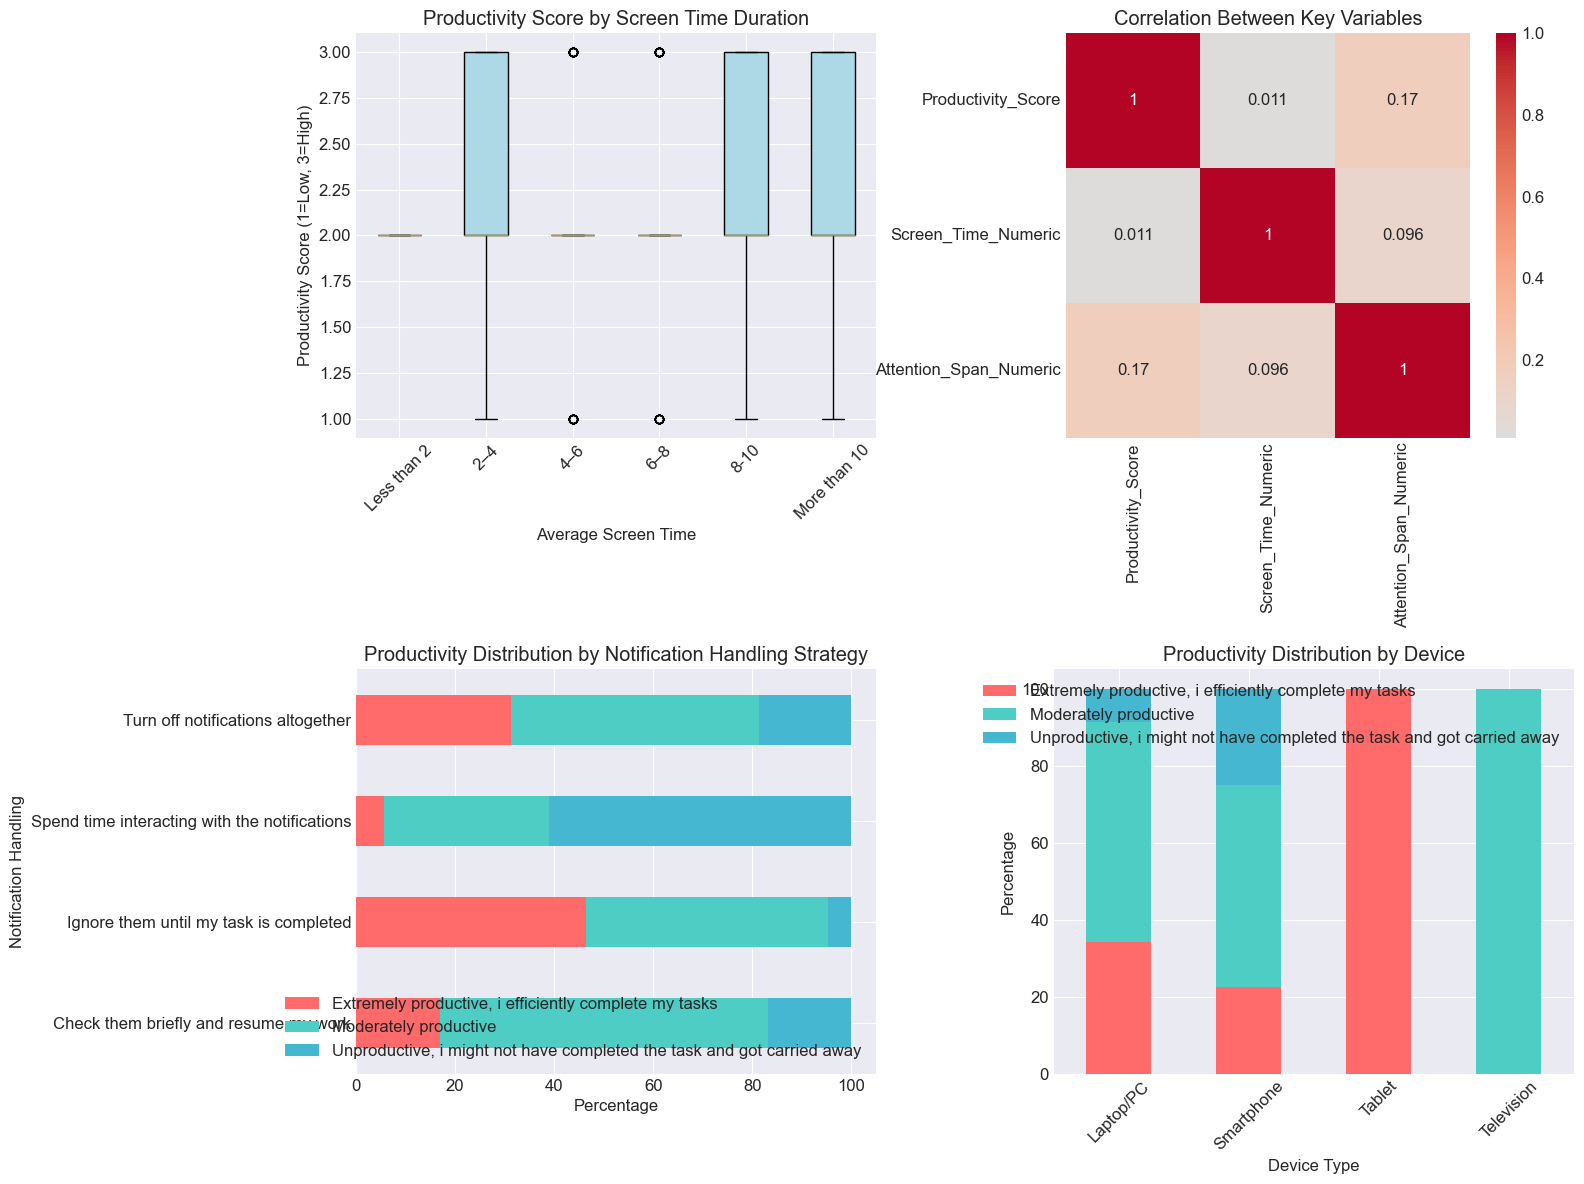


Visualization saved as 'eda_visualizations.png'


In [12]:
fig = plt.figure(figsize=(16, 12))

ax1 = fig.add_subplot(2, 2, 1)
screen_time_order = ['Less than 2', '2–4', '4–6', '6–8', '8-10', 'More than 10']
box_data = []
for st in screen_time_order:
    mask = df_clean['Average Screen Time'] == st
    box_data.append(df_clean[mask]['Productivity_Score'].dropna())
bp = ax1.boxplot(box_data, labels=screen_time_order, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax1.set_xlabel('Average Screen Time')
ax1.set_ylabel('Productivity Score (1=Low, 3=High)')
ax1.set_title('Productivity Score by Screen Time Duration')
ax1.tick_params(axis='x', rotation=45)

ax2 = fig.add_subplot(2, 2, 2)
correlation_data = df_clean[['Productivity_Score', 'Screen_Time_Numeric', 'Attention_Span_Numeric']].dropna()
corr_matrix = correlation_data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax2, square=True)
ax2.set_title('Correlation Between Key Variables')

ax3 = fig.add_subplot(2, 2, 3)
notif_productivity = pd.crosstab(df_clean['Notification Handling'], df_clean['Productivity'], normalize='index') * 100
notif_productivity.plot(kind='barh', stacked=True, ax=ax3, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
ax3.set_xlabel('Percentage')
ax3.set_title('Productivity Distribution by Notification Handling Strategy')
ax3.legend(loc='lower right')

ax4 = fig.add_subplot(2, 2, 4)
device_productivity = pd.crosstab(df_clean['Device'], df_clean['Productivity'], normalize='index') * 100
device_productivity.plot(kind='bar', stacked=True, ax=ax4, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
ax4.set_xlabel('Device Type')
ax4.set_ylabel('Percentage')
ax4.set_title('Productivity Distribution by Device')
ax4.legend(loc='upper right')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nVisualization saved as 'eda_visualizations.png'")

In [13]:
avg_productivity = df_clean.groupby('Average Screen Time')['Productivity_Score'].agg(['mean', 'count', 'std']).round(2)
print(avg_productivity)

correlation, p_value = pearsonr(
    df_clean['Screen_Time_Numeric'].dropna(), 
    df_clean['Productivity_Score'].dropna()
)
print(f"Correlation between Screen Time and Productivity: {correlation:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant correlation (p < 0.05)")
else:
    print("Result: No statistically significant correlation")

contingency_age = pd.crosstab(df_clean['Age Group'], df_clean['Productivity'])
chi2, p, dof, expected = chi2_contingency(contingency_age)
print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

contingency_env = pd.crosstab(df_clean['Environment'], df_clean['Productivity'])
chi2_env, p_env, dof_env, expected_env = chi2_contingency(contingency_env)
print(f"Chi-square statistic: {chi2_env:.3f}")
print(f"P-value: {p_env:.4f}")

strategy_productivity = df_clean.groupby('Work Strategy')['Productivity_Score'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(strategy_productivity.round(2))

                     mean  count   std
Average Screen Time                   
2–4                  2.18     22  0.66
4–6                  2.02     51  0.68
6–8                  2.08     50  0.63
8-10                 2.07     43  0.70
Less than 2          2.00      1   NaN
More than 10         2.14     29  0.74
Correlation between Screen Time and Productivity: 0.011
P-value: 0.8824
Result: No statistically significant correlation
Chi-square statistic: 11.180
P-value: 0.1917
Degrees of freedom: 8
Chi-square statistic: 9.540
P-value: 0.1454
                                                    mean  count
Work Strategy                                                  
Use some productivity tool (e.g, timers, blockers)  2.25     12
Eliminate all distractions                          2.11     46
Take regular breaks                                 2.09     67
None, i prefer to work without any strategies       2.03     71


In [14]:
app_impact = df_clean.groupby('App_Helpfulness')['Productivity_Score'].agg(['mean', 'count'])
app_impact.index = ['No Usage', 'Found Not Helpful', 'Found Extremely Helpful']
print("\nProductivity Score by App Helpfulness Perception:")
print(app_impact.round(2))

total_users = len(df_clean)
app_users = df_clean[df_clean['App_Helpfulness'] > 0].shape[0]
print(f"\nProductivity app users: {app_users} out of {total_users} ({app_users/total_users*100:.1f}%)")

extremely_helpful = df_clean[df_clean['App_Helpfulness'] == 2].shape[0]
print(f"Found extremely helpful: {extremely_helpful} ({extremely_helpful/app_users*100:.1f}% of users)" if app_users > 0 else "No app users found")

app_users_score = df_clean[df_clean['App_Helpfulness'] > 0]['Productivity_Score'].mean()
non_app_users_score = df_clean[df_clean['App_Helpfulness'] == 0]['Productivity_Score'].mean()
print(f"\nAverage productivity score - App users: {app_users_score:.2f}")
print(f"Average productivity score - Non-app users: {non_app_users_score:.2f}")
print(f"Difference: {app_users_score - non_app_users_score:+.2f}")


Productivity Score by App Helpfulness Perception:
                         mean  count
No Usage                 2.07    120
Found Not Helpful        1.91     32
Found Extremely Helpful  2.25     44

Productivity app users: 76 out of 196 (38.8%)
Found extremely helpful: 44 (57.9% of users)

Average productivity score - App users: 2.11
Average productivity score - Non-app users: 2.07
Difference: +0.04


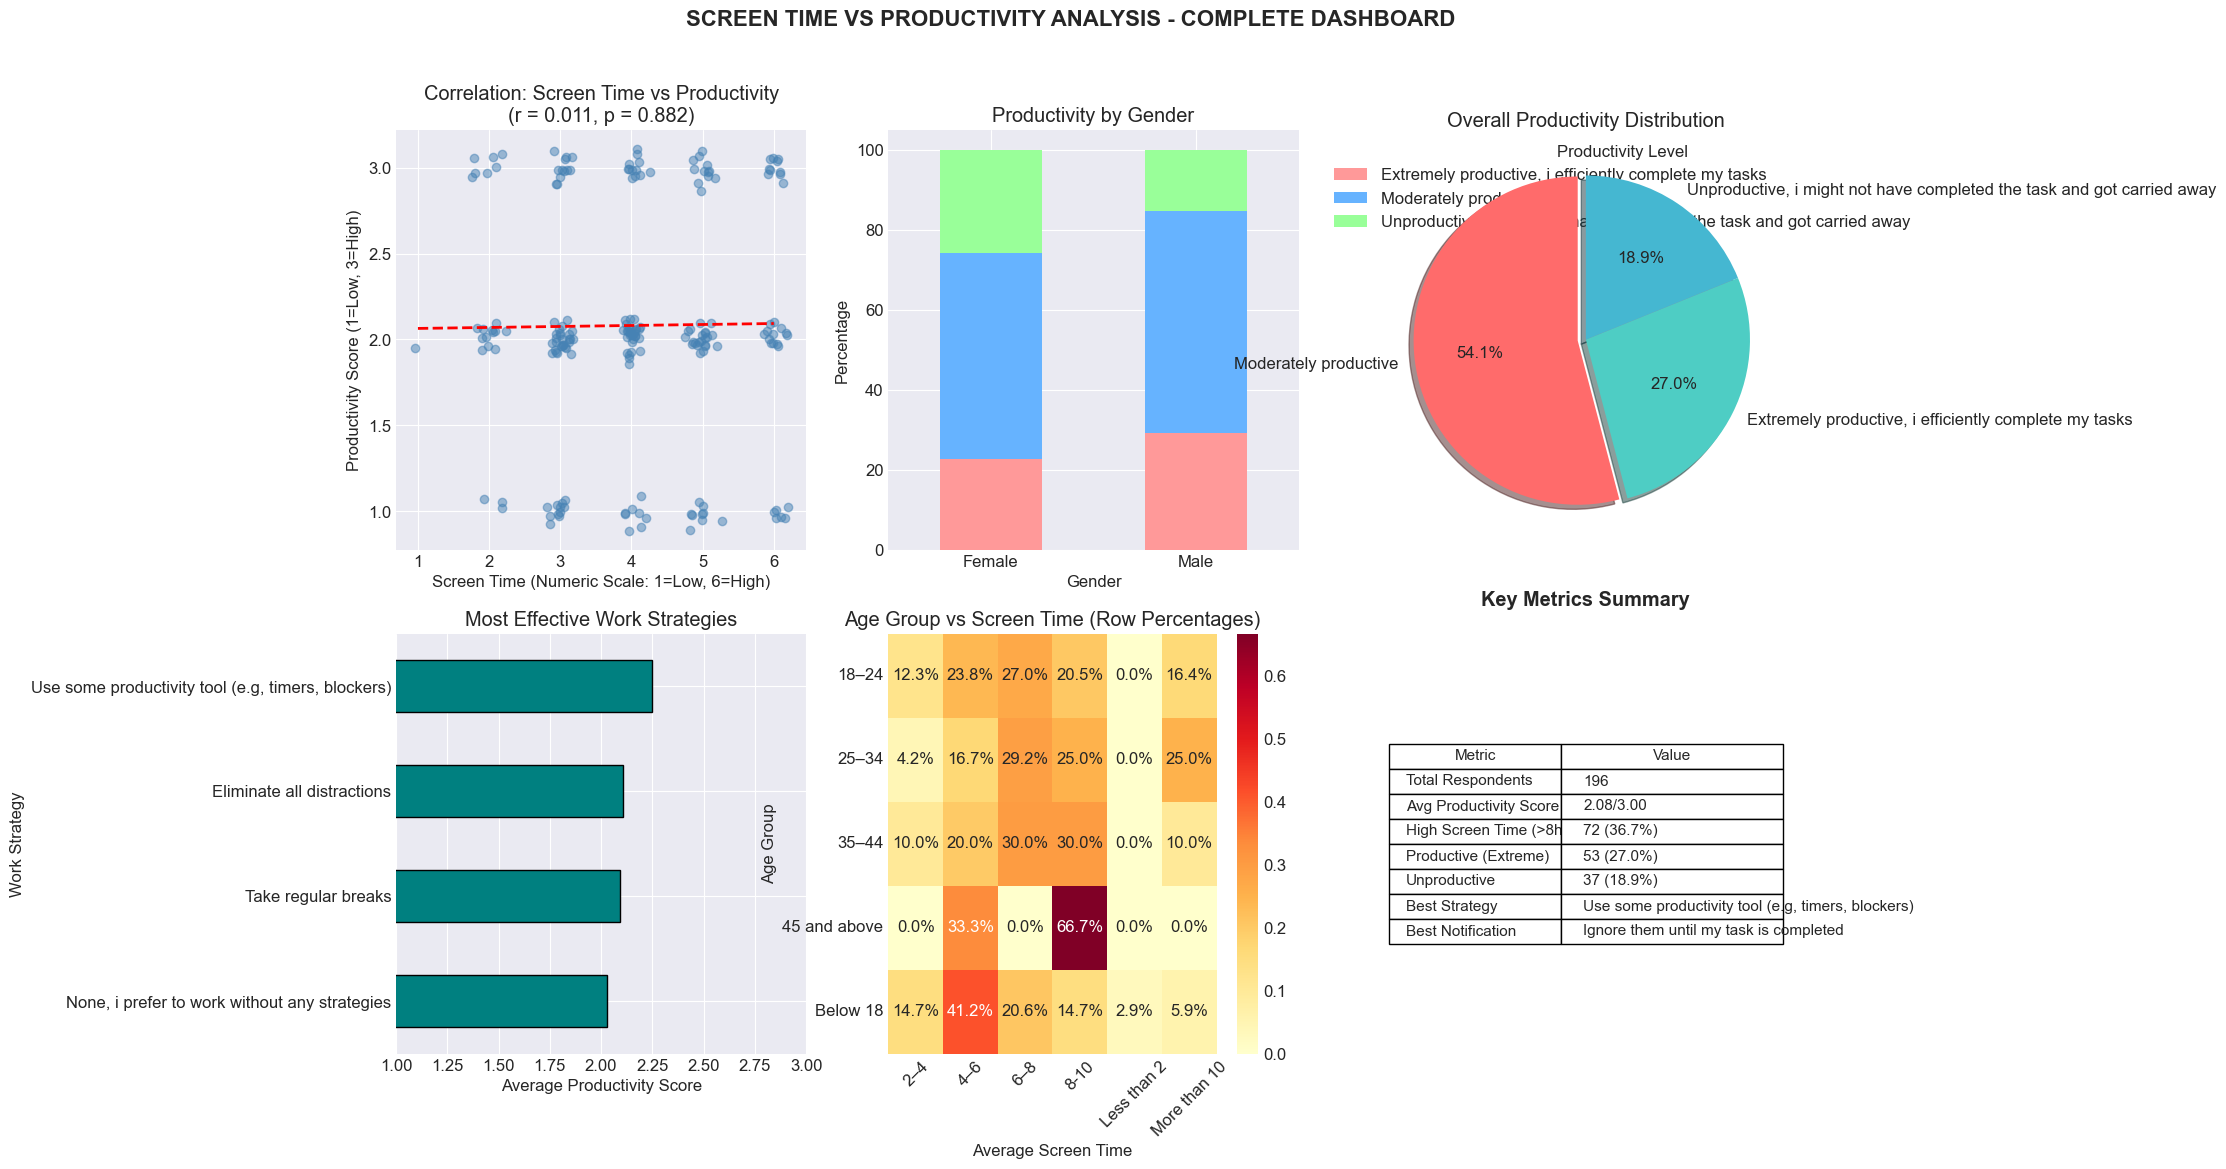


Dashboard saved as 'productivity_dashboard.png'


In [15]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('SCREEN TIME VS PRODUCTIVITY ANALYSIS - COMPLETE DASHBOARD', fontsize=16, fontweight='bold')

ax1 = fig.add_subplot(2, 3, 1)
x_jitter = df_clean['Screen_Time_Numeric'] + np.random.normal(0, 0.1, len(df_clean))
y_jitter = df_clean['Productivity_Score'] + np.random.normal(0, 0.05, len(df_clean))
ax1.scatter(x_jitter, y_jitter, alpha=0.5, color='steelblue')
z = np.polyfit(df_clean['Screen_Time_Numeric'].dropna(), df_clean['Productivity_Score'].dropna(), 1)
p = np.poly1d(z)
ax1.plot(sorted(df_clean['Screen_Time_Numeric'].dropna()), 
         p(sorted(df_clean['Screen_Time_Numeric'].dropna())), 
         'r--', linewidth=2)
ax1.set_xlabel('Screen Time (Numeric Scale: 1=Low, 6=High)')
ax1.set_ylabel('Productivity Score (1=Low, 3=High)')
ax1.set_title(f'Correlation: Screen Time vs Productivity\n(r = {correlation:.3f}, p = {p_value:.3f})')

ax2 = fig.add_subplot(2, 3, 2)
gender_productivity = pd.crosstab(df_clean['Gender'], df_clean['Productivity'], normalize='index') * 100
gender_productivity.plot(kind='bar', stacked=True, ax=ax2, color=['#ff9999', '#66b3ff', '#99ff99'])
ax2.set_title('Productivity by Gender')
ax2.set_ylabel('Percentage')
ax2.set_xlabel('Gender')
ax2.legend(title='Productivity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=0)

ax3 = fig.add_subplot(2, 3, 3)
prod_counts = df_clean['Productivity'].value_counts()
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1']
explode = (0.05, 0, 0)
ax3.pie(prod_counts.values, labels=prod_counts.index, autopct='%1.1f%%', 
        colors=colors, explode=explode, shadow=True, startangle=90)
ax3.set_title('Overall Productivity Distribution')

ax4 = fig.add_subplot(2, 3, 4)
strategy_avg = df_clean.groupby('Work Strategy')['Productivity_Score'].mean().sort_values()
strategy_avg.plot(kind='barh', ax=ax4, color='teal', edgecolor='black')
ax4.set_xlabel('Average Productivity Score')
ax4.set_title('Most Effective Work Strategies')
ax4.set_xlim(1, 3)

ax5 = fig.add_subplot(2, 3, 5)
age_screen_crosstab = pd.crosstab(df_clean['Age Group'], df_clean['Average Screen Time'], normalize='index')
sns.heatmap(age_screen_crosstab, annot=True, fmt='.1%', cmap='YlOrRd', ax=ax5)
ax5.set_title('Age Group vs Screen Time (Row Percentages)')
ax5.tick_params(axis='x', rotation=45)

ax6 = fig.add_subplot(2, 3, 6)
ax6.axis('tight')
ax6.axis('off')
summary_data = [
    ['Total Respondents', len(df_clean)],
    ['Avg Productivity Score', f"{df_clean['Productivity_Score'].mean():.2f}/3.00"],
    ['High Screen Time (>8hrs)', f"{(df_clean['Screen_Time_Numeric'] >= 5).sum()} ({((df_clean['Screen_Time_Numeric'] >= 5).sum()/len(df_clean)*100):.1f}%)"],
    ['Productive (Extreme)', f"{(df_clean['Productivity_Score'] == 3).sum()} ({((df_clean['Productivity_Score'] == 3).sum()/len(df_clean)*100):.1f}%)"],
    ['Unproductive', f"{(df_clean['Productivity_Score'] == 1).sum()} ({((df_clean['Productivity_Score'] == 1).sum()/len(df_clean)*100):.1f}%)"],
    ['Best Strategy', strategy_avg.index[-1] if len(strategy_avg) > 0 else 'N/A'],
    ['Best Notification', df_clean.groupby('Notification Handling')['Productivity_Score'].mean().idxmax()],
]
table = ax6.table(cellText=summary_data, colLabels=['Metric', 'Value'], 
                  cellLoc='left', loc='center', colWidths=[0.35, 0.45])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)
ax6.set_title('Key Metrics Summary', pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('productivity_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDashboard saved as 'productivity_dashboard.png'")